In [2]:
# ── Cell 1: Imports & Load Data ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
import joblib

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/My Drive/IoT Intrusion Detection/data/'

# Load unscaled data — Random Forest doesn't need feature scaling
X_train = pd.read_csv(DATA_PATH + 'X_train.csv')
X_test  = pd.read_csv(DATA_PATH + 'X_test.csv')
y_train = np.load(DATA_PATH + 'y_train.npy')
y_test  = np.load(DATA_PATH + 'y_test.npy')

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train attack rate: {y_train.mean()*100:.1f}%")

Mounted at /content/drive
X_train: (2032036, 43)
X_test:  (508010, 43)
y_train attack rate: 12.6%


In [3]:
# ── Cell 2: Train Random Forest ───────────────────────────────────────────────
# n_estimators=100            -> 100 decision trees in the forest
# max_depth=20                -> limits tree depth to prevent overfitting & save memory
# class_weight='balanced'     ->  compensates for the 12.6% attack imbalance
# n_jobs=-1                   -> use all CPU cores (speeds up training significantly)
# random_state=42             -> reproducibility

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42)

print("Training Random Forest... this may take some time")
rf.fit(X_train, y_train)
print("Training complete")

Training Random Forest... (this may take 3–5 minutes on Colab)
Training complete ✓


In [6]:
# ── Cell 3: Evaluate ──────────────────────────────────────────────────────────
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)

print("=" * 45)
print(f"  Accuracy : {accuracy*100:.2f}%")
print(f"  F1 Score : {f1:.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

  Accuracy : 99.12%
  F1 Score : 0.9663

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    443753
      Attack       0.94      1.00      0.97     64257

    accuracy                           0.99    508010
   macro avg       0.97      0.99      0.98    508010
weighted avg       0.99      0.99      0.99    508010



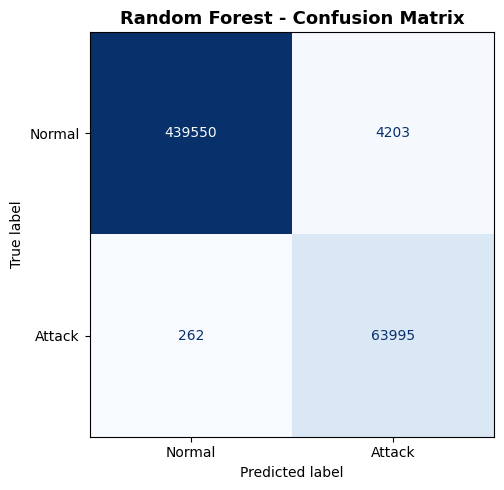

Saved -> rf_confusion_matrix.png 


In [9]:
# ── Cell 4: Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal', 'Attack'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest - Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH + 'rf_confusion_matrix.png', dpi=150)
plt.show()
print("Saved -> rf_confusion_matrix.png ")

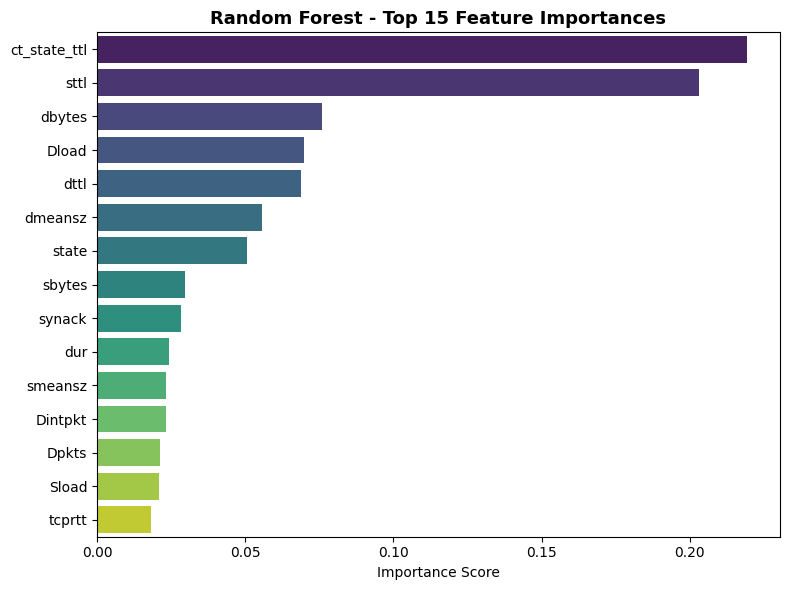

Saved -> rf_feature_importance.png


In [14]:

# ── Cell 5: Feature Importance ────────────────────────────────────────────────
feature_names = X_train.columns.tolist()
importances   = rf.feature_importances_

feat_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=feat_df, x='importance', y='feature', hue='feature', palette='viridis', legend=False, ax=ax)
ax.set_title('Random Forest - Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DATA_PATH + 'rf_feature_importance.png', dpi=150)
plt.show()
print("Saved -> rf_feature_importance.png")

In [15]:
# ── Cell 6: Save Model ────────────────────────────────────────────────────────
joblib.dump(rf, DATA_PATH + 'random_forest_model.pkl')
print("Model saved -> random_forest_model.pkl")

# Save results for the comparison notebook later
results = {
    'model':    'Random Forest',
    'accuracy': accuracy,
    'f1_score': f1
}
pd.DataFrame([results]).to_csv(DATA_PATH + 'rf_results.csv', index=False)
print("Results saved -> rf_results.csv")

Model saved -> random_forest_model.pkl
Results saved -> rf_results.csv
